In [529]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import pymap3d as pm
import math
import seaborn as sb
import datetime as dt
import time

In [530]:
# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/STATIC_GPS_FINAL.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/KINE_GPS_FINAL.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

G = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/TESTGC.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
GRC = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/TESTGRC.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
GREC = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/TESTGREC.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
GEC = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/TESTGEC.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
GC = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/TESTG.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/BASE_STATIC_GPS_ONLY.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/C_VBARF_STATIC_GPS_ONLY.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

# BASE = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/DCB_OLD.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])
# VBARF = pd.read_csv('/Users/sergeidolin/RTKLIB/app/consapp/rnx2rtkp/gcc/DCB_NEW.pos', sep=' ', skipinitialspace=True, parse_dates=['UTC'])

In [531]:
def RMSE(data: pd.DataFrame):
    E_values = data.loc[data['E'].isna() == False, 'E']
    N_values = data.loc[data['N'].isna() == False, 'N']
    U_values = data.loc[data['U'].isna() == False, 'U']

    ppp_E_last = math.sqrt(sum(E_values**2) / len(E_values))
    ppp_N_last = math.sqrt(sum(N_values**2) / len(N_values))
    ppp_U_last = math.sqrt(sum(U_values**2) / len(U_values))

    print(f'RMSE E = {ppp_E_last:.4f}')
    print(f'RMSE N = {ppp_N_last:.4f}')
    print(f'RMSE U = {ppp_U_last:.4f}')

    print(f'2D = {((ppp_E_last+ppp_N_last)/2)*2.1460:.4f}')
    print(f'3D = {((ppp_E_last+ppp_N_last+ppp_U_last)*0.3333)*2.5003:.4f}')

In [532]:
ref_point = {'x': 54.9872753361111,
             'y': 82.864814275,
             'z': 109.647}

ref_point = {'x': 16.262307523,
             'y': -61.527534867,
             'z': -25.567}


In [533]:
def reduction(df):
    enu = []
    for i in range(len(df)):
        enu.append(pm.geodetic2enu(df['latitude(deg)'][i], df['longitude(deg)'][i], df['height(m)'][i], 
                                ref_point['x'], ref_point['y'], ref_point['z']))

    df[['E','N','U']] = enu
    # df['N'] += 0.1055
    # df['U'] -= 0.4187

    return df

In [534]:
def avg(df):
    enu = []
    avg_point_b = df['latitude(deg)'].mean()
    avg_point_l = df['longitude(deg)'].mean()
    avg_point_h = df['height(m)'].mean()
    for i in range(len(df)):
        enu.append(pm.geodetic2enu(df['latitude(deg)'][i], df['longitude(deg)'][i], df['height(m)'][i], 
                                avg_point_b, avg_point_l, avg_point_h))

    df[['E','N','U']] = enu
    # df['N'] += 0.1055
    # df['U'] -= 0.4187

    return df

In [535]:
import numpy as np
import pandas as pd
from scipy.stats import t

# Уровни значимости (α)
alphas = [0.4]  

# Степени свободы (ν)
dfs = [i for i in range(1,31)]

# Создаем таблицу
table = pd.DataFrame(index=dfs, columns=alphas)

for df in dfs:
    for alpha in alphas:
        # Двусторонний тест: t-критическое значение
        t_critical = t.ppf(1 - alpha / 2, df)
        table.loc[df, alpha] = f"{t_critical:.4f}"

# Переименуем индексы и столбцы для наглядности
table.index.name = "Степени свободы (ν)"
table.columns.name = "Уровень значимости (α)"
table.columns = [f"α = {a}" for a in alphas]

print("Таблица критических значений t-распределения (двусторонние):")
print(np.array(table['α = 0.4']))

Таблица критических значений t-распределения (двусторонние):
['1.3764' '1.0607' '0.9785' '0.9410' '0.9195' '0.9057' '0.8960' '0.8889'
 '0.8834' '0.8791' '0.8755' '0.8726' '0.8702' '0.8681' '0.8662' '0.8647'
 '0.8633' '0.8620' '0.8610' '0.8600' '0.8591' '0.8583' '0.8575' '0.8569'
 '0.8562' '0.8557' '0.8551' '0.8546' '0.8542' '0.8538']


RMSE E = 0.0161
RMSE N = 0.0038
RMSE U = 0.0290
2D = 0.0214
3D = 0.0408
RMSE E = 0.0125
RMSE N = 0.0031
RMSE U = 0.0181
2D = 0.0167
3D = 0.0281
RMSE E = 0.0181
RMSE N = 0.0029
RMSE U = 0.0058
2D = 0.0225
3D = 0.0223
RMSE E = 0.0175
RMSE N = 0.0000
RMSE U = 0.0100
2D = 0.0188
3D = 0.0229
RMSE E = 0.0176
RMSE N = 0.0004
RMSE U = 0.0059
2D = 0.0193
3D = 0.0199


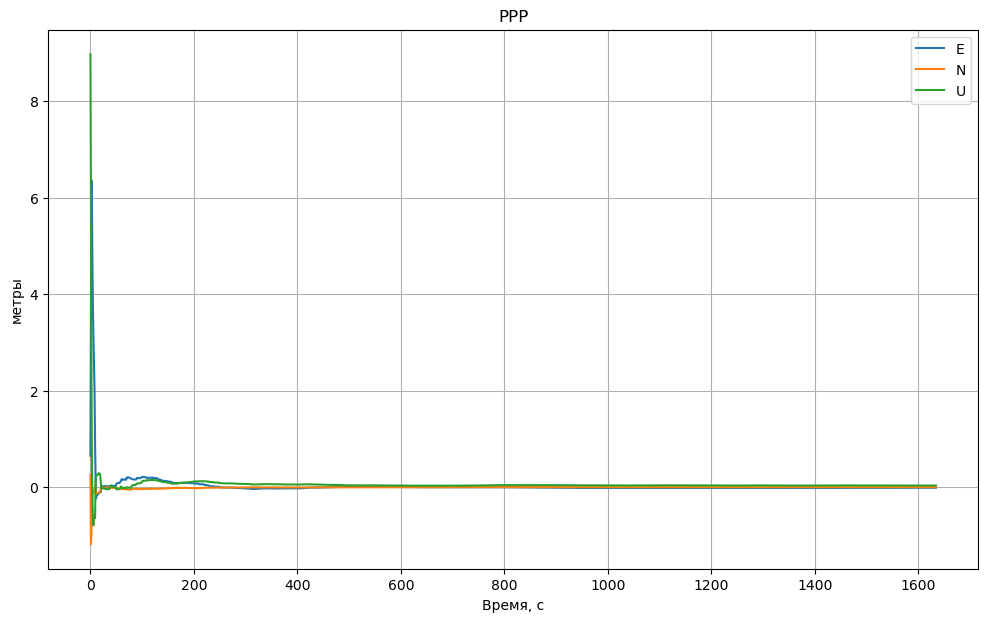

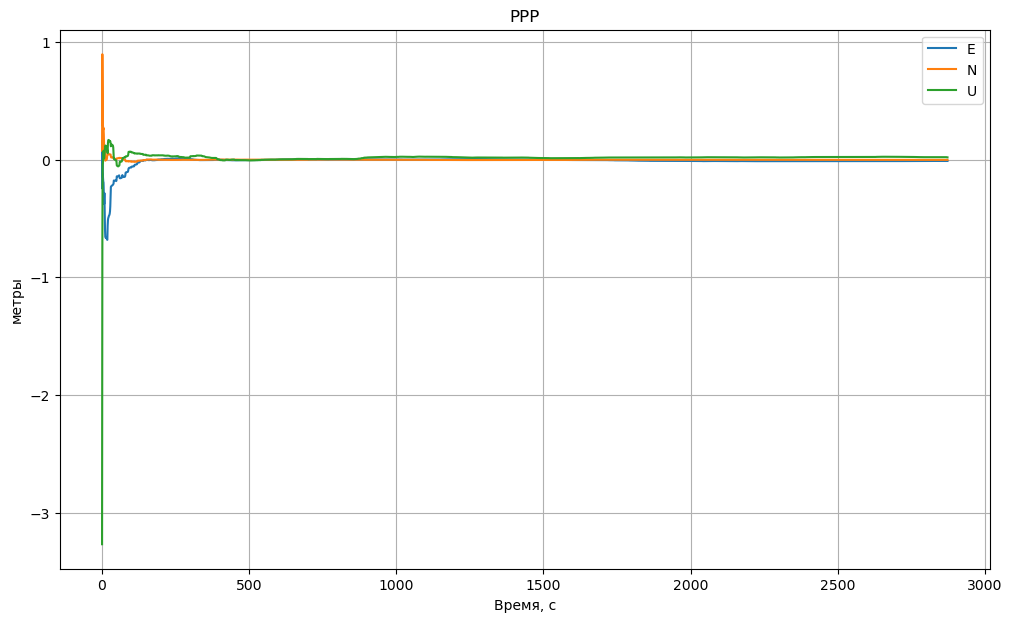

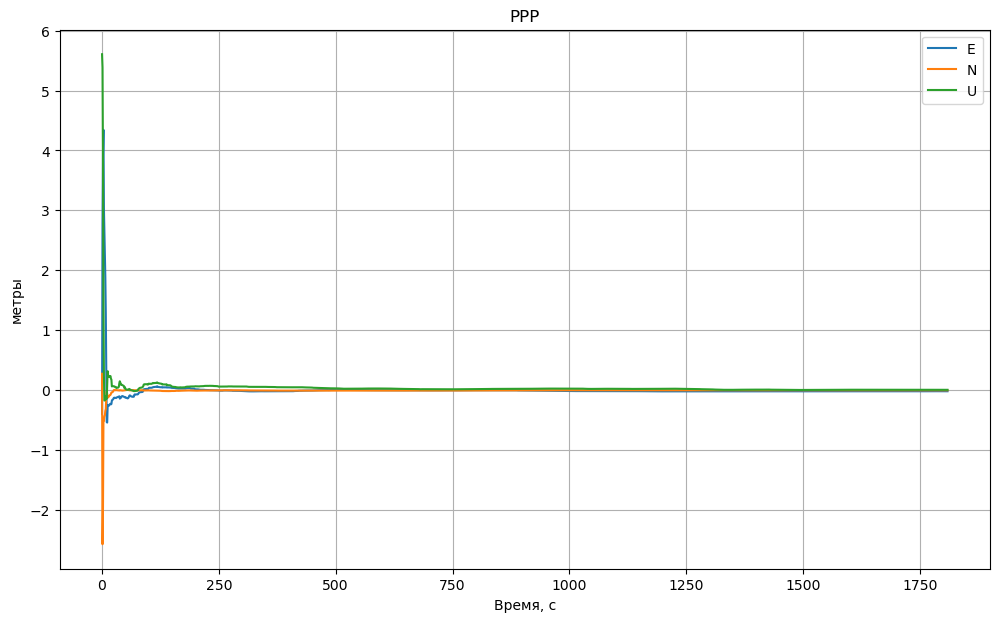

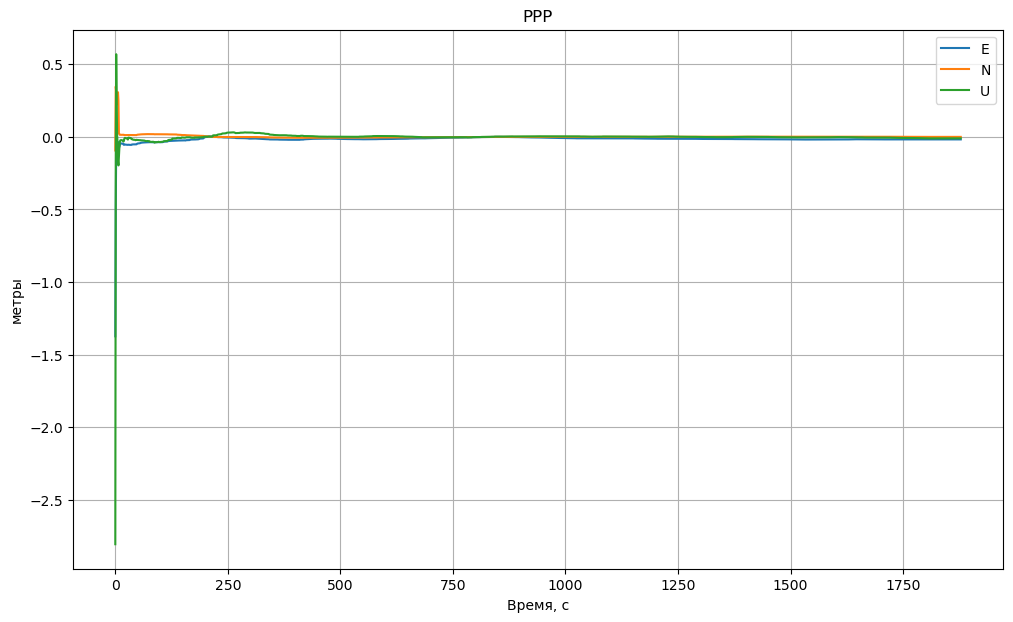

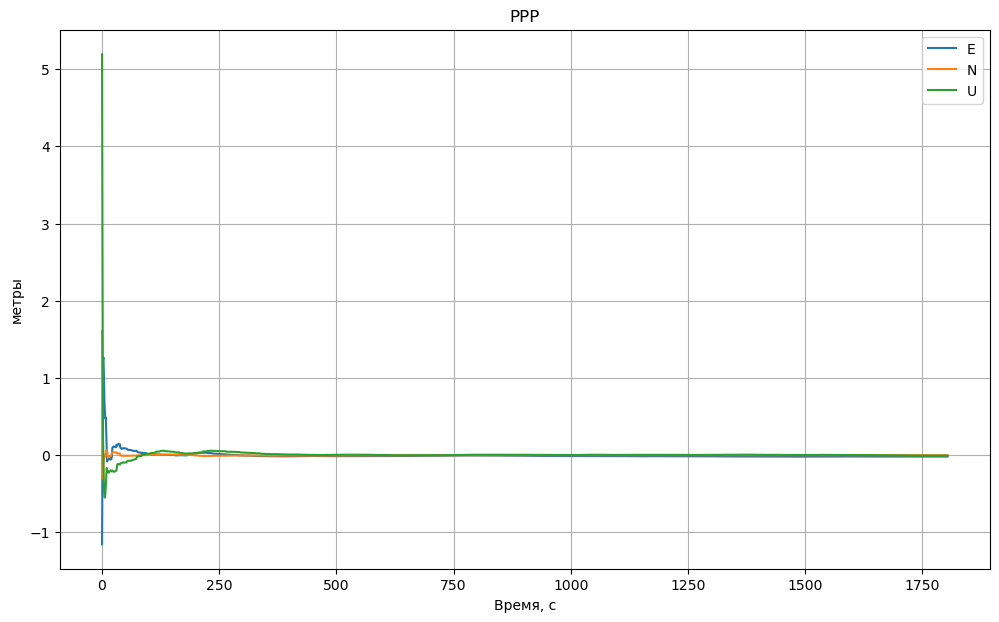

In [536]:
for i in [G,GC,GRC,GREC,GEC]:
    i = reduction(i)
    RMSE(i[-3:])
    i[:].plot(y=['E', 'N', 'U'], style='-', 
        grid=True, figsize=(12,7), xlabel='Время, с', 
        ylabel='метры', legend=True, title='PPP');

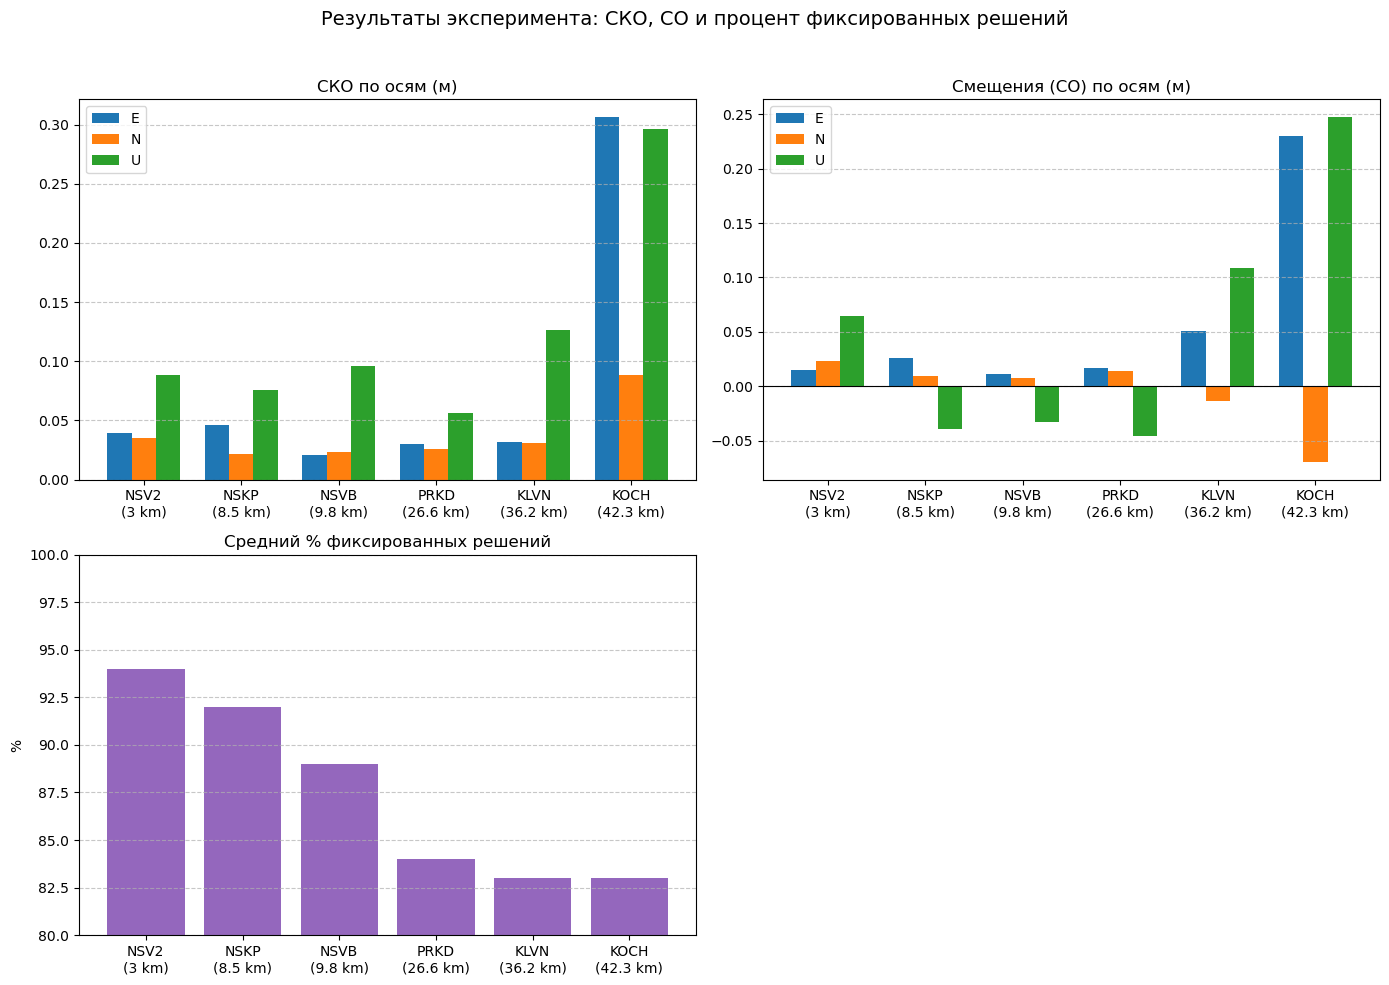

In [537]:
import matplotlib.pyplot as plt
import numpy as np

# Расстояния до БС (в км)
stations = ['NSV2\n(3 km)', 'NSKP\n(8.5 km)', 'NSVB\n(9.8 km)', 'PRKD\n(26.6 km)', 'KLVN\n(36.2 km)', 'KOCH\n(42.3 km)']
distances_km = [3, 8.5, 9.8, 26.6, 36.2, 42.3]

# СКО по осям (м)
sco_E = [0.039, 0.046, 0.021, 0.030, 0.032, 0.306]
sco_N = [0.035, 0.022, 0.023, 0.026, 0.031, 0.088]
sco_U = [0.088, 0.076, 0.096, 0.056, 0.126, 0.296]

# Смещения (СО) по осям (м); "–" заменено на np.nan
so_E = [0.015, 0.026, 0.011, 0.017, 0.051, 0.230]
so_N = [0.023, 0.009, 0.008, 0.014, -0.014, -0.070]
so_U = [0.065, -0.039, -0.033, -0.046, 0.109, 0.248]

# Процент фиксированных решений
fix_pct = [94, 92, 89, 84, 83, 83]

# Настройка графиков
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Результаты эксперимента: СКО, СО и процент фиксированных решений', fontsize=14)

x = np.arange(len(stations))
width = 0.25

# 1. СКО
axs[0, 0].bar(x - width, sco_E, width, label='E', color='tab:blue')
axs[0, 0].bar(x,       sco_N, width, label='N', color='tab:orange')
axs[0, 0].bar(x + width, sco_U, width, label='U', color='tab:green')
axs[0, 0].set_title('СКО по осям (м)')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(stations)
axs[0, 0].legend()
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Смещения (СО)
axs[0, 1].bar(x - width, so_E, width, label='E', color='tab:blue')
axs[0, 1].bar(x,       so_N, width, label='N', color='tab:orange')
axs[0, 1].bar(x + width, so_U, width, label='U', color='tab:green')
axs[0, 1].set_title('Смещения (СО) по осям (м)')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(stations)
axs[0, 1].legend()
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
axs[0, 1].axhline(0, color='black', linewidth=0.8)

# 3. Процент фиксированных решений
axs[1, 0].bar(stations, fix_pct, color='tab:purple')
axs[1, 0].set_title('Средний % фиксированных решений')
axs[1, 0].set_ylabel('%')
axs[1, 0].set_ylim(80, 100)
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Пустой график (или можно добавить комбинированный)
axs[1, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

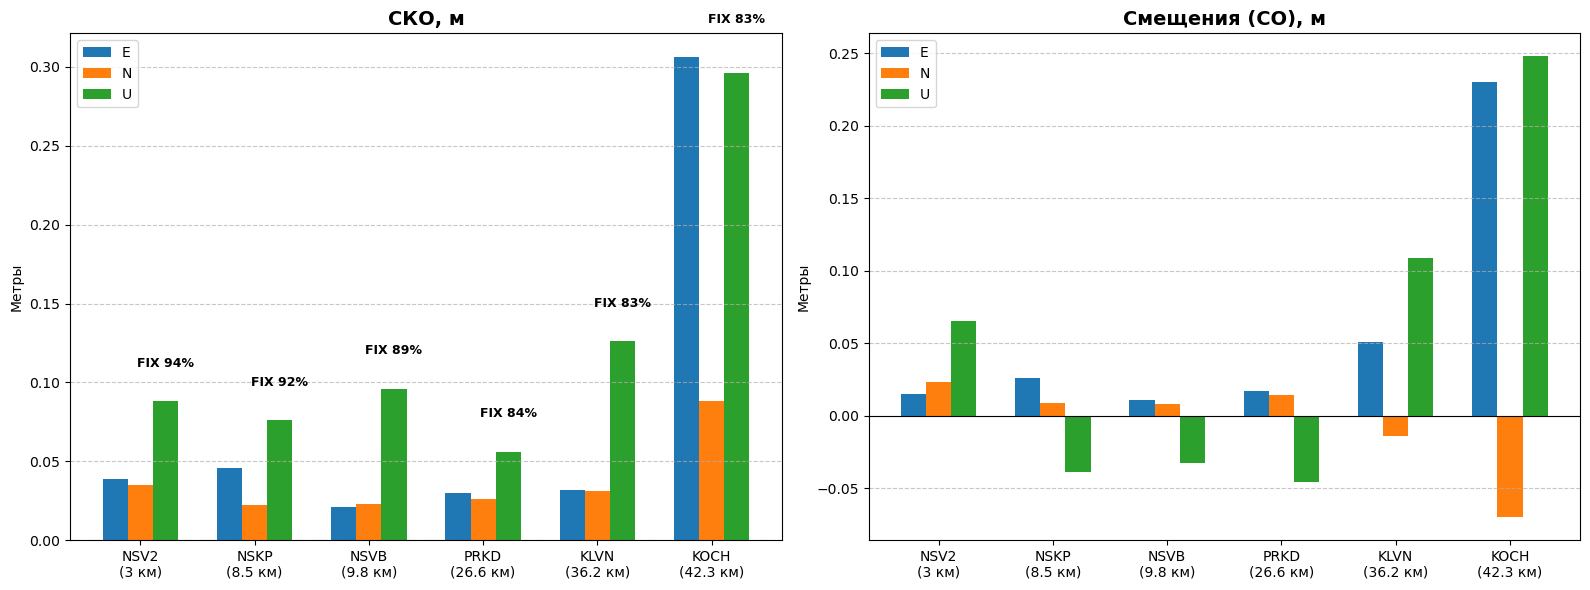

In [538]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
stations = ['NSV2\n(3 км)', 'NSKP\n(8.5 км)', 'NSVB\n(9.8 км)', 
            'PRKD\n(26.6 км)', 'KLVN\n(36.2 км)', 'KOCH\n(42.3 км)']

# СКО (м)
sco = {
    'E': [0.039, 0.046, 0.021, 0.030, 0.032, 0.306],
    'N': [0.035, 0.022, 0.023, 0.026, 0.031, 0.088],
    'U': [0.088, 0.076, 0.096, 0.056, 0.126, 0.296]
}

# Смещения (СО, м)
smesh = {
    'E': [0.015, 0.026, 0.011, 0.017, 0.051, 0.230],
    'N': [0.023, 0.009, 0.008, 0.014, -0.014, -0.070],
    'U': [0.065, -0.039, -0.033, -0.046, 0.109, 0.248]
}

# Процент фиксированных решений
fix_percent = [94, 92, 89, 84, 83, 83]

x = np.arange(len(stations))
width = 0.22  # немного уже, чтобы оставить место для подписей

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Цвета для осей
colors = {'E': '#1f77b4', 'N': '#ff7f0e', 'U': '#2ca02c'}

# 1. СКО
for i, (comp, vals) in enumerate(sco.items()):
    offset = (i - 1) * width  # центрируем группу
    bars = ax1.bar(x + offset, vals, width, label=comp, color=colors[comp])
    # Надписи с процентами — только один раз над центром группы
    if comp == 'U':  # выводим над последним (верхним) столбцом в группе
        for j, p in enumerate(fix_percent):
            ax1.text(x[j] + offset, max(sco['E'][j], sco['N'][j], sco['U'][j]) + 0.02,
                     f'FIX {p}%', ha='center', va='bottom', fontsize=9, weight='bold')

ax1.set_title('СКО, м', fontsize=14, weight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(stations)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_ylabel('Метры')

# 2. Смещения (СО)
for i, (comp, vals) in enumerate(smesh.items()):
    offset = (i - 1) * width
    bars = ax2.bar(x + offset, vals, width, label=comp, color=colors[comp])

ax2.set_title('Смещения (СО), м', fontsize=14, weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(stations)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_ylabel('Метры')

plt.tight_layout()
plt.show()

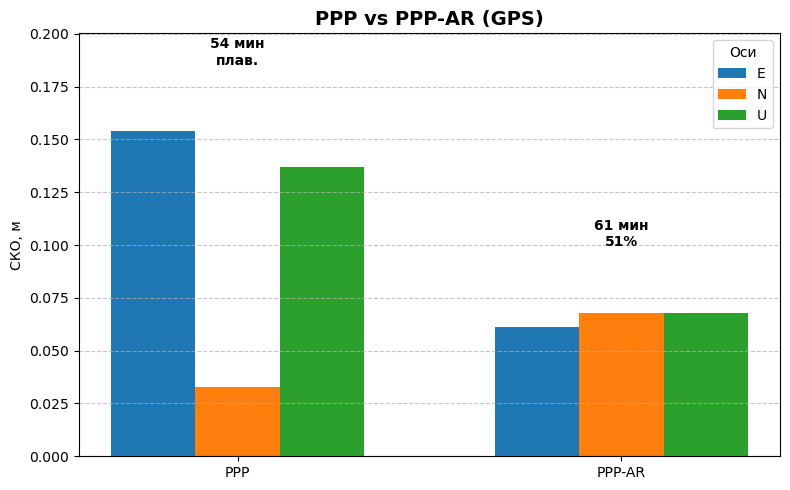

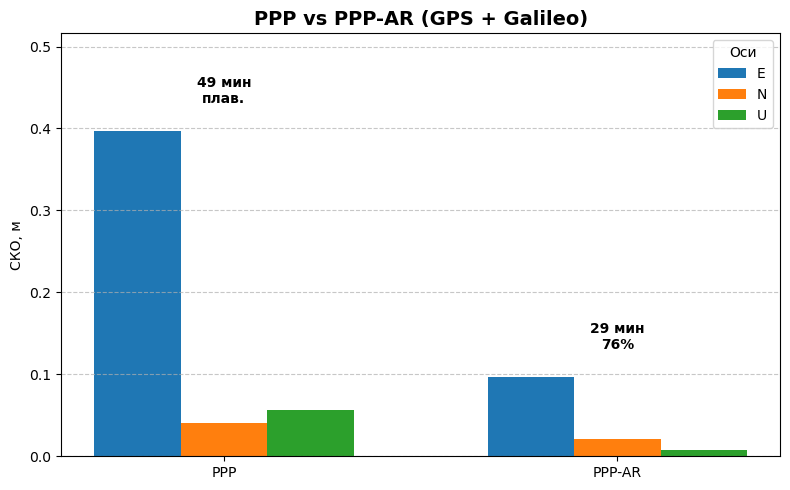

In [539]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
modes = ['PPP', 'PPP-AR']
x = np.arange(len(modes))
width = 0.22

# Цвета осей
colors = {'E': '#1f77b4', 'N': '#ff7f0e', 'U': '#2ca02c'}

# === GPS ===
sco_gps = {
    'PPP': {'E': 0.154, 'N': 0.033, 'U': 0.137},
    'PPP-AR': {'E': 0.061, 'N': 0.068, 'U': 0.068}
}
conv_gps = {'PPP': 54, 'PPP-AR': 61}
fix_gps = {'PPP': 0, 'PPP-AR': 51}  # PPP — плавающее, поэтому 0%

# === GPS+Galileo ===
sco_gal = {
    'PPP': {'E': 0.397, 'N': 0.041, 'U': 0.057},
    'PPP-AR': {'E': 0.097, 'N': 0.021, 'U': 0.008}
}
conv_gal = {'PPP': 49, 'PPP-AR': 29}
fix_gal = {'PPP': 0, 'PPP-AR': 76}

def plot_comparison(sco, conv, fix, title):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.array([0, 1])  # PPP, PPP-AR

    # Построение столбцов
    for i, comp in enumerate(['E', 'N', 'U']):
        offset = (i - 1) * width
        vals = [sco['PPP'][comp], sco['PPP-AR'][comp]]
        ax.bar(x + offset, vals, width, label=comp, color=colors[comp])

    # Надписи над группами
    for i, mode in enumerate(['PPP', 'PPP-AR']):
        # Время сходимости
        time_str = f"{conv[mode]} мин"
        # Процент фиксации
        if fix[mode] > 0:
            fix_str = f"{fix[mode]}%"
        else:
            fix_str = "плав."
        # Позиция над макс. столбцом в группе
        y_max = max(sco[mode]['E'], sco[mode]['N'], sco[mode]['U'])
        ax.text(x[i], y_max + 0.03, f"{time_str}\n{fix_str}", 
                ha='center', va='bottom', fontsize=10, weight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['PPP', 'PPP-AR'])
    ax.set_ylabel('СКО, м')
    ax.set_title(title, fontsize=14, weight='bold')
    ax.legend(title='Оси')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, max(
        max(sco['PPP'].values()),
        max(sco['PPP-AR'].values())
    ) * 1.3)
    plt.tight_layout()
    return fig

# Строим два графика
fig1 = plot_comparison(sco_gps, conv_gps, fix_gps, 'PPP vs PPP-AR (GPS)')
fig2 = plot_comparison(sco_gal, conv_gal, fix_gal, 'PPP vs PPP-AR (GPS + Galileo)')

plt.show()